In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [41]:
import os
import platform

print(platform.platform())
print(os.path.exists('/content/drive'))
print(os.path.exists('/content/drive/MyDrive'))
print(os.cpu_count())

Linux-6.6.122+-x86_64-with-glibc2.35
True
True
2


In [43]:
!pwd
!ls /content
!ls /content/drive

/content
drive  sample_data
MyDrive


In [44]:
!free -h

               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.3Gi       8.7Gi       2.0Mi       2.6Gi        11Gi
Swap:             0B          0B          0B


/content
drive  sample_data
MyDrive


In [ ]:
!apt-get install openjdk-17-jdk-headless -qq > /dev/null
!pip install -q pyspark==3.5.6

In [2]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("HomeCredit")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .config("spark.sql.repl.eagerEval.enabled", "true")
    .getOrCreate()
)

print(spark.version)

3.5.6


In [10]:
df = spark.read.csv(r'/content/drive/MyDrive/Colab Notebooks/home-credit-risk/data/application_train.csv', header=True, inferSchema=True)
df.show(5)

+----------+------+------------------+-----------+------------+---------------+------------+----------------+----------+-----------+---------------+---------------+----------------+--------------------+--------------------+-----------------+--------------------------+----------+-------------+-----------------+---------------+-----------+----------+--------------+---------------+----------------+----------+----------+---------------+---------------+--------------------+---------------------------+--------------------------+-----------------------+--------------------------+--------------------------+---------------------------+----------------------+----------------------+-----------------------+--------------------+-------------------+------------------+-------------------+--------------+----------------+---------------------------+------------------+--------------+-------------+-------------+-------------+-------------+------------+--------------------+--------------+-----------------

In [32]:
feature_groups = {

    # --------------------------------------------------
    # Key & Target
    # --------------------------------------------------
    "key": [
        "SK_ID_CURR"
    ],

    "target": [
        "TARGET"
    ],

    # --------------------------------------------------
    # Binary Flags (0/1)
    # --------------------------------------------------
    "binary_flags": [
        "FLAG_MOBIL",
        "FLAG_EMP_PHONE",
        "FLAG_WORK_PHONE",
        "FLAG_CONT_MOBILE",
        "FLAG_PHONE",
        "FLAG_EMAIL",

        "REG_REGION_NOT_LIVE_REGION",
        "REG_REGION_NOT_WORK_REGION",
        "LIVE_REGION_NOT_WORK_REGION",

        "REG_CITY_NOT_LIVE_CITY",
        "REG_CITY_NOT_WORK_CITY",
        "LIVE_CITY_NOT_WORK_CITY",

        "FLAG_DOCUMENT_2",
        "FLAG_DOCUMENT_3",
        "FLAG_DOCUMENT_4",
        "FLAG_DOCUMENT_5",
        "FLAG_DOCUMENT_6",
        "FLAG_DOCUMENT_7",
        "FLAG_DOCUMENT_8",
        "FLAG_DOCUMENT_9",
        "FLAG_DOCUMENT_10",
        "FLAG_DOCUMENT_11",
        "FLAG_DOCUMENT_12",
        "FLAG_DOCUMENT_13",
        "FLAG_DOCUMENT_14",
        "FLAG_DOCUMENT_15",
        "FLAG_DOCUMENT_16",
        "FLAG_DOCUMENT_17",
        "FLAG_DOCUMENT_18",
        "FLAG_DOCUMENT_19",
        "FLAG_DOCUMENT_20",
        "FLAG_DOCUMENT_21"
    ],

    # --------------------------------------------------
    # Binary Categoricals
    # --------------------------------------------------
    "binary_categorical": [
        "CODE_GENDER",
        "FLAG_OWN_CAR",
        "FLAG_OWN_REALTY",
        "NAME_CONTRACT_TYPE",
        "EMERGENCYSTATE_MODE"
    ],

    # --------------------------------------------------
    # Low Cardinality Categoricals
    # --------------------------------------------------
    "categorical_low_cardinality": [
        "NAME_TYPE_SUITE",
        "NAME_INCOME_TYPE",
        "NAME_EDUCATION_TYPE",
        "NAME_FAMILY_STATUS",
        "NAME_HOUSING_TYPE",
        "WEEKDAY_APPR_PROCESS_START",
        "FONDKAPREMONT_MODE",
        "HOUSETYPE_MODE",
        "WALLSMATERIAL_MODE"
    ],

    # --------------------------------------------------
    # High Cardinality Categoricals
    # --------------------------------------------------
    "categorical_high_cardinality": [
        "OCCUPATION_TYPE",
        "ORGANIZATION_TYPE"
    ],

    # --------------------------------------------------
    # Income & Credit
    # --------------------------------------------------
    "credit_income": [
        "AMT_INCOME_TOTAL",
        "AMT_CREDIT",
        "AMT_ANNUITY",
        "AMT_GOODS_PRICE"
    ],

    # --------------------------------------------------
    # Family
    # --------------------------------------------------
    "family": [
        "CNT_CHILDREN",
        "CNT_FAM_MEMBERS"
    ],

    # --------------------------------------------------
    # Demographics / Customer History
    # --------------------------------------------------
    "demographics": [
        "DAYS_BIRTH",
        "DAYS_EMPLOYED",
        "DAYS_REGISTRATION",
        "DAYS_ID_PUBLISH",
        "DAYS_LAST_PHONE_CHANGE",
        "OWN_CAR_AGE",

        "REGION_POPULATION_RELATIVE",
        "REGION_RATING_CLIENT",
        "REGION_RATING_CLIENT_W_CITY",

        "HOUR_APPR_PROCESS_START"
    ],

    # --------------------------------------------------
    # External Scores
    # --------------------------------------------------
    "external_scores": [
        "EXT_SOURCE_1",
        "EXT_SOURCE_2",
        "EXT_SOURCE_3"
    ],

    # --------------------------------------------------
    # Social Circle
    # --------------------------------------------------
    "social": [
        "OBS_30_CNT_SOCIAL_CIRCLE",
        "DEF_30_CNT_SOCIAL_CIRCLE",
        "OBS_60_CNT_SOCIAL_CIRCLE",
        "DEF_60_CNT_SOCIAL_CIRCLE"
    ],

    # --------------------------------------------------
    # Credit Bureau Requests
    # --------------------------------------------------
    "bureau": [
        "AMT_REQ_CREDIT_BUREAU_HOUR",
        "AMT_REQ_CREDIT_BUREAU_DAY",
        "AMT_REQ_CREDIT_BUREAU_WEEK",
        "AMT_REQ_CREDIT_BUREAU_MON",
        "AMT_REQ_CREDIT_BUREAU_QRT",
        "AMT_REQ_CREDIT_BUREAU_YEAR"
    ],

    # --------------------------------------------------
    # Housing Features
    # --------------------------------------------------
    "housing": [
        "APARTMENTS_AVG",
        "BASEMENTAREA_AVG",
        "YEARS_BEGINEXPLUATATION_AVG",
        "YEARS_BUILD_AVG",
        "COMMONAREA_AVG",
        "ELEVATORS_AVG",
        "ENTRANCES_AVG",
        "FLOORSMAX_AVG",
        "FLOORSMIN_AVG",
        "LANDAREA_AVG",
        "LIVINGAPARTMENTS_AVG",
        "LIVINGAREA_AVG",
        "NONLIVINGAPARTMENTS_AVG",
        "NONLIVINGAREA_AVG",

        "APARTMENTS_MODE",
        "BASEMENTAREA_MODE",
        "YEARS_BEGINEXPLUATATION_MODE",
        "YEARS_BUILD_MODE",
        "COMMONAREA_MODE",
        "ELEVATORS_MODE",
        "ENTRANCES_MODE",
        "FLOORSMAX_MODE",
        "FLOORSMIN_MODE",
        "LANDAREA_MODE",
        "LIVINGAPARTMENTS_MODE",
        "LIVINGAREA_MODE",
        "NONLIVINGAPARTMENTS_MODE",
        "NONLIVINGAREA_MODE",

        "APARTMENTS_MEDI",
        "BASEMENTAREA_MEDI",
        "YEARS_BEGINEXPLUATATION_MEDI",
        "YEARS_BUILD_MEDI",
        "COMMONAREA_MEDI",
        "ELEVATORS_MEDI",
        "ENTRANCES_MEDI",
        "FLOORSMAX_MEDI",
        "FLOORSMIN_MEDI",
        "LANDAREA_MEDI",
        "LIVINGAPARTMENTS_MEDI",
        "LIVINGAREA_MEDI",
        "NONLIVINGAPARTMENTS_MEDI",
        "NONLIVINGAREA_MEDI",

        "TOTALAREA_MODE"
    ]
}

## Missing Value Analysis

In [33]:
from pyspark.sql.functions import col, count, when, round

In [35]:
feature_to_group = {}

for group, features in feature_groups.items():
    for feature in features:
        feature_to_group[feature] = group

In [36]:
from pyspark.sql import Row
from pyspark.sql.functions import col, count, when

total_rows = df.count()

results = []

for column in df.columns:

    missing_count = (
        df.select(
            count(
                when(col(column).isNull(), column)
            ).alias("missing")
        )
        .collect()[0]["missing"]
    )

    missing_pct = round(
        missing_count * 100 / total_rows,
        2
    )

    results.append(
        Row(
            column=column,
            group=feature_to_group.get(
                column,
                "ungrouped"
            ),
            missing_count=missing_count,
            missing_pct=missing_pct
        )
    )

missing_report = spark.createDataFrame(results)

missing_report.orderBy(
    col("missing_pct").desc()
).show(100, truncate=False)

PySparkTypeError: [NOT_COLUMN_OR_STR] Argument `col` should be a Column or str, got float.

In [17]:
all_features = []
for cols in feature_groups.values():
    all_features.extend(cols)

print(f"Total number of features: {len(all_features)}")
print(f"Total number of unique features: {len(set(all_features))}")

missing = set(df.columns) - set(all_features)
print(f"Number of missing features: {len(missing)}")
print(f"Missing features: {missing}")

Total number of features: 122
Total number of unique features: 122
Number of missing features: 0
Missing features: set()


In [ ]:
total_rows = df.count()

missing_df = (
    df.select([
        (
            count(when(col(c).isNull(), c)) / total_rows * 100
        ).alias(c)
        for c in df.columns
    ])
)

missing_long = (
    missing_df
    .selectExpr(
        f"stack({len(df.columns)}, " +
        ",".join([f"'{c}', `{c}`" for c in df.columns]) +
        ") as (column_name, missing_pct)"
    )
    .orderBy(col("missing_pct").desc())
)

missing_long.show(50, truncate=False)

+----------------------------+------------------+
|column_name                 |missing_pct       |
+----------------------------+------------------+
|COMMONAREA_AVG              |69.87229725115525 |
|COMMONAREA_MODE             |69.87229725115525 |
|COMMONAREA_MEDI             |69.87229725115525 |
|NONLIVINGAPARTMENTS_AVG     |69.43296337366793 |
|NONLIVINGAPARTMENTS_MODE    |69.43296337366793 |
|NONLIVINGAPARTMENTS_MEDI    |69.43296337366793 |
|FONDKAPREMONT_MODE          |68.38617155158677 |
|LIVINGAPARTMENTS_AVG        |68.35495315614726 |
|LIVINGAPARTMENTS_MODE       |68.35495315614726 |
|LIVINGAPARTMENTS_MEDI       |68.35495315614726 |
|FLOORSMIN_AVG               |67.84862980511267 |
|FLOORSMIN_MODE              |67.84862980511267 |
|FLOORSMIN_MEDI              |67.84862980511267 |
|YEARS_BUILD_AVG             |66.49778381911543 |
|YEARS_BUILD_MODE            |66.49778381911543 |
|YEARS_BUILD_MEDI            |66.49778381911543 |
|OWN_CAR_AGE                 |65.9908100848425  |


## Target Distribution

In [28]:
df.groupBy('TARGET').count().withColumn("pct",round(col("count")/ df.count() * 100, 2)).show()

+------+------+-----+
|TARGET| count|  pct|
+------+------+-----+
|     1| 24825| 8.07|
|     0|282686|91.93|
+------+------+-----+



In [6]:
# W2: Home Credit Default Risk - data loading and initial inspection
import numpy as np

# Load the data (adjust file path if needed)
import pandas as pd

df = pd.read_csv(r'/content/drive/MyDrive/Colab Notebooks/home-credit-risk/data/application_train.csv')

# Basic info
print("Shape:", df.shape)
print("\nTarget distribution:\n", df['TARGET'].value_counts(normalize=True))

# Check data types
print("\nData types:\n", df.dtypes.value_counts())

# Missing values summary (top 10 columns by % missing)
missing_pct = df.isnull().mean() * 100
print("\nTop 10 columns by missing %:\n", missing_pct.sort_values(ascending=False).head(10))

# First rows to see structure
print("\nFirst 2 rows (first 5 columns):\n", df.iloc[:2, :5])

Shape: (307511, 122)

Target distribution:
 TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

Data types:
 float64    65
int64      41
object     16
Name: count, dtype: int64

Top 10 columns by missing %:
 COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_MEDI             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_MODE       68.354953
dtype: float64

First 2 rows (first 5 columns):
    SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR
0      100002       1         Cash loans           M            N
1      100003       0         Cash loans           F            N


In [14]:
# Feature engineering pipeline for Home Credit
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np

# Assume df is already loaded
# Drop columns with >50% missing
missing_pct = df.isnull().mean() * 100
cols_to_drop = missing_pct[missing_pct > 50].index.tolist()
df_clean = df.drop(columns=cols_to_drop)
print(f"Dropped {len(cols_to_drop)} columns with >50% missing. Remaining columns: {df_clean.shape[1]}")

# Handle DAYS_EMPLOYED: impute 0, create missing flag
df_clean['DAYS_EMPLOYED_MISSING'] = df_clean['DAYS_EMPLOYED'].isnull().astype(int)
df_clean['DAYS_EMPLOYED'] = df_clean['DAYS_EMPLOYED'].fillna(0)

# Create debt-to-income ratio
df_clean['DEBT_TO_INCOME'] = df_clean['AMT_CREDIT'] / df_clean['AMT_INCOME_TOTAL']

# Separate features and target
X = df_clean.drop(columns=['TARGET', 'SK_ID_CURR'])  # SK_ID_CURR is just an ID
y = df_clean['TARGET']

# Identify numeric and categorical columns (simplified for demonstration)
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
# Keep only low-cardinality categoricals for one-hot encoding (e.g., <10 unique)
categorical_cols = [c for c in categorical_cols if X[c].nunique() < 10]

# Preprocessor: scale numeric, one-hot encode categoricals
preprocessor = ColumnTransformer([
    ('num', RobustScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

# Split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")
print(f"Train target distribution:\n{y_train.value_counts(normalize=True)}")

Dropped 41 columns with >50% missing. Remaining columns: 81
Train size: (246008, 81), Test size: (61503, 81)
Train target distribution:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


In [15]:
# Full pipeline with ColumnTransformer and model training
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.impute import SimpleImputer

# Assume X_train, X_test, y_train, y_test are already defined from previous steps
# Identify numeric and categorical columns (excluding target and ID)
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
# Keep low-cardinality categoricals (e.g., <10 unique)
categorical_cols = [c for c in categorical_cols if X_train[c].nunique() < 10]

# Preprocessor
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', RobustScaler())
    ]), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

# Define models
models = {
    'Logistic Regression': LogisticRegression(solver='saga', max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

# Train and evaluate
results = {}
for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    pipeline.fit(X_train, y_train)
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred_proba)
    results[name] = auc
    print(f"{name}: ROC-AUC = {auc:.4f}")

print("\nBest model:", max(results, key=results.get))

Logistic Regression: ROC-AUC = 0.7372
Random Forest: ROC-AUC = 0.7113
XGBoost: ROC-AUC = 0.7466

Best model: XGBoost


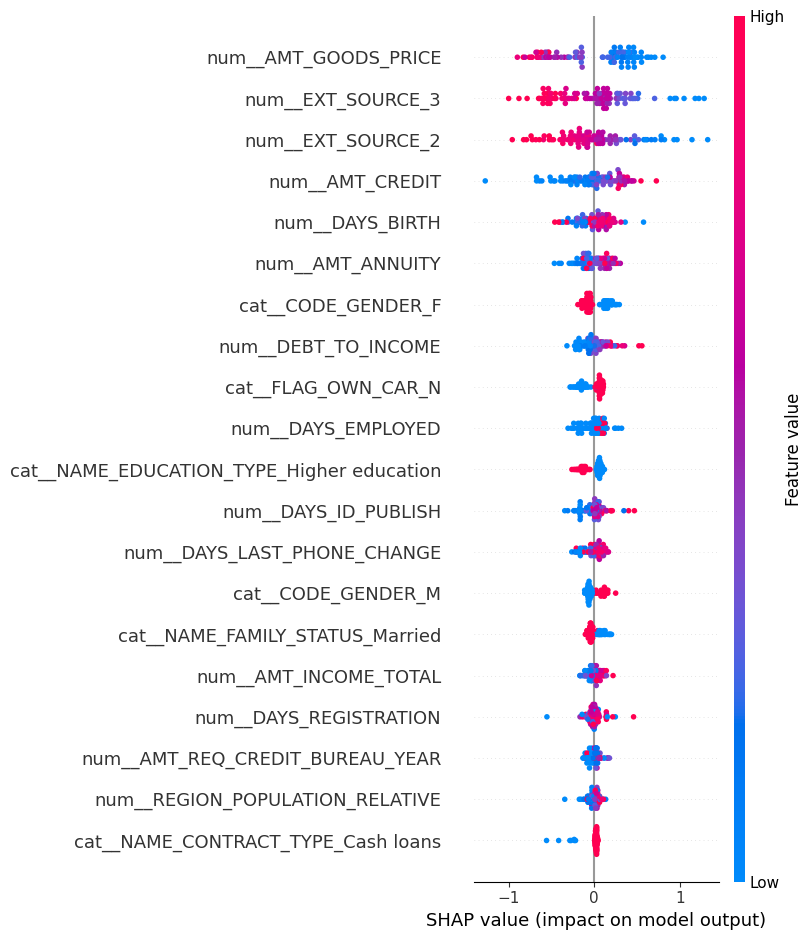

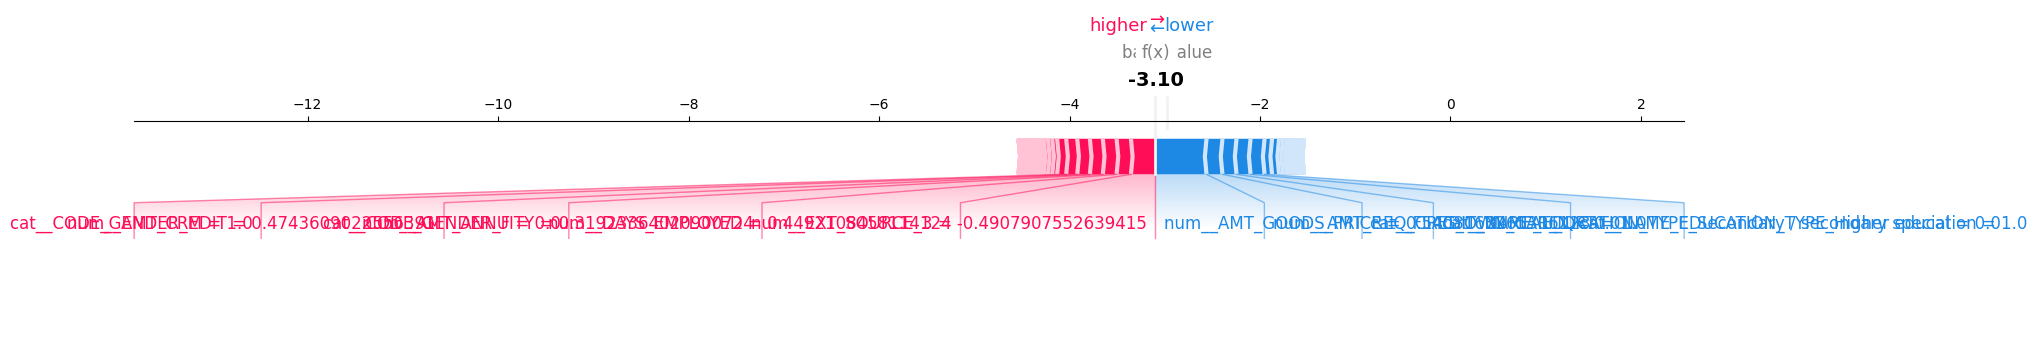

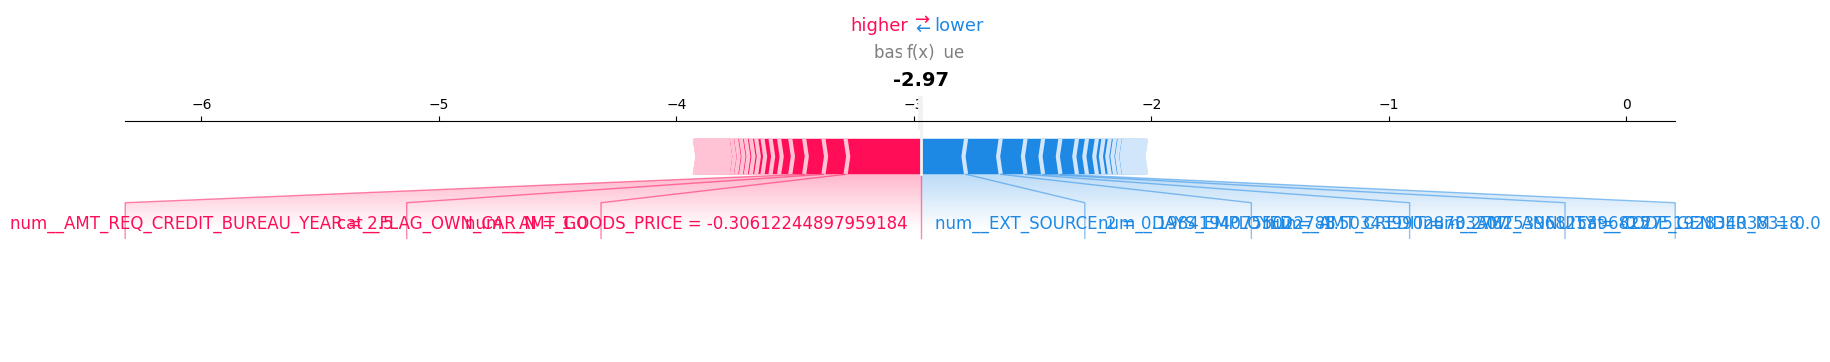

In [16]:
# SHAP analysis for XGBoost
import shap
import numpy as np
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

# -----------------------------
# 1. Train pipeline
# -----------------------------
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=100,
        random_state=42,
        eval_metric='logloss'
    ))
])

final_pipeline.fit(X_train, y_train)

# -----------------------------
# 2. Transform data
# -----------------------------
preprocessor_fitted = final_pipeline.named_steps['preprocessor']
model = final_pipeline.named_steps['classifier']

# Transform train/test
X_train_processed = preprocessor_fitted.transform(X_train)
X_test_processed = preprocessor_fitted.transform(X_test)

# -----------------------------
# 3. Feature names (SAFE way)
# -----------------------------
feature_names = preprocessor_fitted.get_feature_names_out()

# -----------------------------
# 4. Take a small sample (important for speed)
# -----------------------------
X_sample = X_test_processed[:100]

# Convert ONLY sample to dense if needed
if hasattr(X_sample, "toarray"):
    X_sample = X_sample.toarray()

# -----------------------------
# 5. SHAP Explainer (correct one)
# -----------------------------
explainer = shap.TreeExplainer(
    model,
    data=X_sample,  # important
    feature_perturbation="interventional"
)

# Compute SHAP values
shap_values = explainer.shap_values(X_sample)

# Handle binary classification
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# -----------------------------
# 6. Global explanation
# -----------------------------
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names
)

# -----------------------------
# 7. Local explanations (force plots)
# -----------------------------
# Handle expected value for binary classification
expected_value = explainer.expected_value
if isinstance(expected_value, list):
    expected_value = expected_value[1]

shap.initjs()

for i in range(2):
    shap.force_plot(
        expected_value,
        shap_values[i],
        X_sample[i],
        feature_names=feature_names,
        matplotlib=True
    )
    

In [4]:
import torch

print("Torch:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
print("Torch CUDA Version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.12.0+cpu
CUDA Available: False
Torch CUDA Version: None


In [2]:
import sys
print(sys.executable)

c:\Users\user\miniforge3\envs\pytorch-gpu\python.exe
